Benchmark : singleset_256bd.xlsx
  行数=252, 列数=7, dt=3.8702 fs
  时间范围: 0 ~ 971.4 fs

  [已绘制] multiset $\chi'=64$ (Krylov expanded)
    时间范围: 0 ~ 963.7 fs,  最大MAE=8.9646e-04,  均值MAE=1.4197e-04
  [已绘制] multiset $\chi'=64$ (Random expanded)
    时间范围: 0 ~ 963.7 fs,  最大MAE=9.3249e-04,  均值MAE=2.1422e-04

✅ 已保存: FMO_MAE_vs_256bd.png


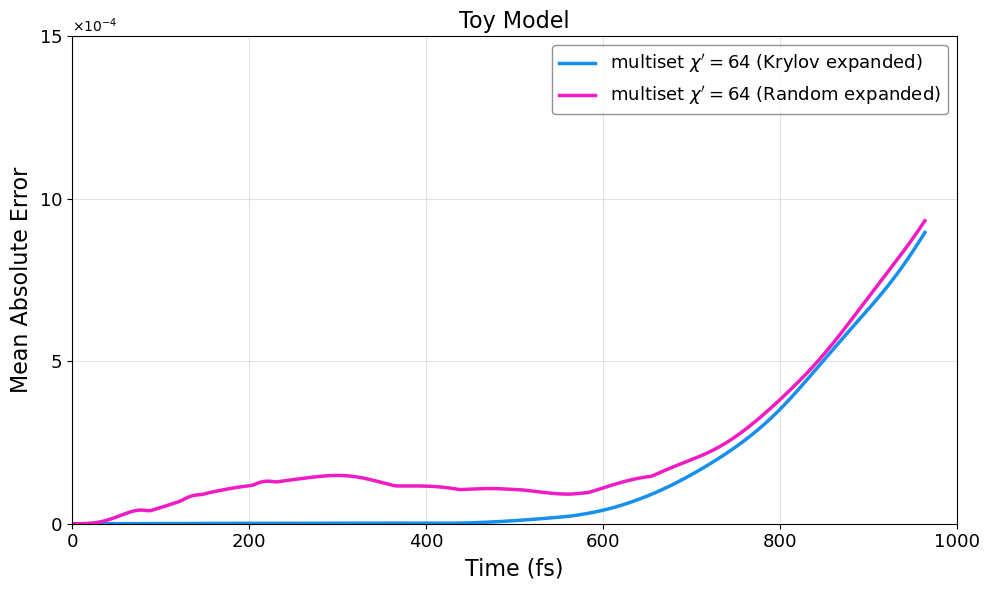

In [18]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_fmo_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算其余三个文件的 Mean Absolute Error 并绘图。
    """

    # ============================================================
    # 1. 路径配置（只需修改此处）
    # ============================================================
    test_dir = "."   # ← 修改为你的文件夹路径，若在同目录则保持 "."

    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    # 需要对比的三个文件（按 bond dimension 从小到大排列）
    data_files = [
        # os.path.join(test_dir, "singleset_32bd.xlsx"),
        # os.path.join(test_dir, "multiset_32bd.xlsx"),
        # os.path.join(test_dir, "multiset_32bd_old.xlsx"),
        # os.path.join(test_dir, "singleset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd_old.xlsx"),
        # os.path.join(test_dir, "singleset_128bd.xlsx"),
        # os.path.join(test_dir, "multiset_128bd.xlsx"),
    ]

    # ============================================================
    # 2. 样式配置：(标签, 颜色, 线型, 线宽)
    # ============================================================
    styles = {
        # "singleset_32bd.xlsx":  ("singleset  ($\\chi'=32$)",  "#4df01b", "--",  2.5),
        # "multiset_32bd.xlsx":  ("multiset  ($\\chi'=32$)",  "#2ca02c", "-",  2.5),
        # "multiset_32bd_old.xlsx":  ("multiset_old  ($\\chi'=64$)",  "#4df01b", "--",  2.5),
        # "singleset_64bd.xlsx":  ("singleset $\\chi'=64$ (Krylov expanded)",  "#6ddafe", "--",  2.5),
        "multiset_64bd.xlsx":  ("multiset $\\chi'=64$ (Krylov expanded)",  "#1690ec", "-",  2.5),
        "multiset_64bd_old.xlsx":  ("multiset $\\chi'=64$ (Random expanded)",  "#f01bc5", "-",  2.5),
        # "singleset_128bd.xlsx": ("singleset $\\chi'=128$ (Krylov expanded)", "#ff7e7e", "--",  2.5),
        # "multiset_128bd.xlsx":   ("multiset $\\chi'=128$ (Random expanded)",  "#ff3232", "-", 2.5),
    }

    # ============================================================
    # 3. 时间步长（单位：fs）
    #    dt = 每步原子单位数 × 0.024188843265 fs/a.u.
    #    根据实际步长修改 dt_au
    # ============================================================
    dt_au = 160                          # ← 按需修改
    dt    = dt_au * 0.024188843265       # fs

    # ============================================================
    # 4. 读取 benchmark
    # ============================================================
    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]              # 自动识别列数（FMO 通常为 7 个 site）
    y_bm  = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm  = np.arange(len(y_bm)) * dt

    print(f"Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    # ============================================================
    # 5. 绘图
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        # 读取预测数据
        df_pred = pd.read_excel(fpath, header=None)
        y_pred  = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred  = np.arange(len(y_pred)) * dt

        # 将 benchmark 插值到预测时间轴上
        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算 Mean Absolute Error（对所有 site 取平均）
        mae = np.mean(np.abs(y_pred - y_bm_interp), axis=1)

        ax.plot(x_pred, mae,
                label=label,
                color=color,
                linestyle=ls,
                linewidth=lw)

        print(f"  [已绘制] {label}")
        print(f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
              f"最大MAE={mae.max():.4e},  均值MAE={mae.mean():.4e}")

    # ============================================================
    # 6. 坐标轴与标注
    # ============================================================
    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("Mean Absolute Error", fontsize=16)
    ax.set_title(
        "Toy Model",
        fontsize=16
    )
    ax.set_xlim(left=0,right=1000)
    ax.set_ylim(bottom=0)
    ax.set_yticks([0,0.0005,0.0010,0.0015])
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-4, -4))
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-4, -4))
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("FMO_MAE_vs_256bd.png", dpi=150)
    print("\n✅ 已保存: FMO_MAE_vs_256bd.png")
    plt.show()


plot_fmo_error()


Benchmark : singleset_256bd.xlsx
  行数=252, 列数=7, dt=3.8702 fs
  时间范围: 0 ~ 971.4 fs

  [已绘制] singleset $\chi'=64$ (Krylov expanded)
    时间范围: 0 ~ 971.4 fs,  最大Accumulated Error=4.1770e-04,  均值Accumulated Error=8.2688e-05
  [已绘制] multiset $\chi'=64$ (Krylov expanded)
    时间范围: 0 ~ 963.7 fs,  最大Accumulated Error=1.4074e-04,  均值Accumulated Error=1.9759e-05
  [已绘制] multiset $\chi'=64$ (Random expanded)
    时间范围: 0 ~ 963.7 fs,  最大Accumulated Error=2.1321e-04,  均值Accumulated Error=9.1435e-05

✅ 已保存: FMO_accumulated_error_vs_256bd.png


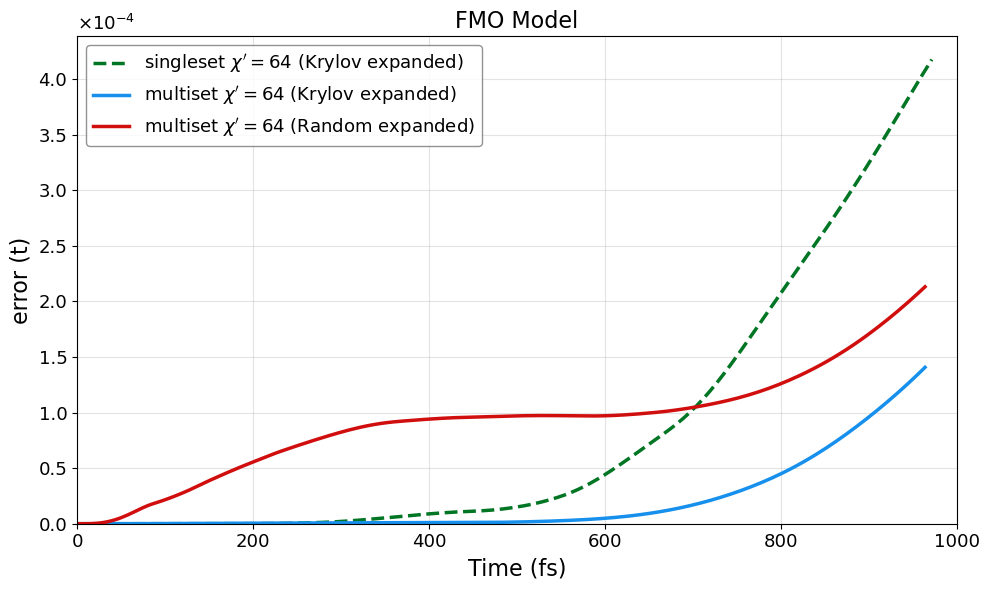

In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_fmo_accumulated_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算 multiset_64bd 与 multiset_64bd_old 的 accumulated error 并绘图。
    """

    test_dir = "."
    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    data_files = [
        os.path.join(test_dir, "singleset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd_old.xlsx"),
    ]

    styles = {
        "singleset_64bd.xlsx":  ("singleset $\\chi'=64$ (Krylov expanded)",  "#007523", "--",  2.5),
        "multiset_64bd.xlsx": ("multiset $\\chi'=64$ (Krylov expanded)", "#1690ec", "-", 2.5),
        "multiset_64bd_old.xlsx": ("multiset $\\chi'=64$ (Random expanded)", "#d10e0e", "-", 2.5),
    }

    dt_au = 160
    dt = dt_au * 0.024188843265

    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]
    y_bm = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm = np.arange(len(y_bm)) * dt

    print("Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        df_pred = pd.read_excel(fpath, header=None)
        y_pred = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred = np.arange(len(y_pred)) * dt

        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算平均累计误差：sum_n integral_0^t |P_n - P_ref_n| dt' / (n_col * t)
        abs_err = np.abs(y_pred - y_bm_interp)
        acc_err = np.zeros(len(x_pred), dtype=float)
        if len(x_pred) > 1:
            dt_seg = np.diff(x_pred)
            seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * dt_seg[:, None]
            cumulative_integral = np.cumsum(seg_integral, axis=0)
            acc_err[1:] = np.sum(cumulative_integral, axis=1) / (n_col * x_pred[1:])

        ax.plot(
            x_pred,
            acc_err,
            label=label,
            color=color,
            linestyle=ls,
            linewidth=lw,
        )

        print(f"  [已绘制] {label}")
        print(
            f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
            f"最大Accumulated Error={acc_err.max():.4e},  均值Accumulated Error={acc_err.mean():.4e}"
        )

    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("error (t)", fontsize=16)
    ax.set_title("FMO Model", fontsize=16)
    ax.set_xlim(left=0, right=1000)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y / 1e-4:.1f}"))
    ax.text(
        0.0,
        1.005,
        r"$\times 10^{-4}$",
        transform=ax.transAxes,
        fontsize=13,
        ha="left",
        va="bottom",
    )
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("FMO_accumulated_error_vs_256bd.png", dpi=150)
    print("\n✅ 已保存: FMO_accumulated_error_vs_256bd.png")
    plt.show()


plot_fmo_accumulated_error()
